# VEP Analysis

In [359]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
    
import pandas as pd
import polars as pl
import seqpro as sp
import numpy as np
import pooch
from tqdm import tqdm
from pathlib import Path
from tempfile import TemporaryDirectory
import genvarloader as gvl

# Local code
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.utils as utils
import src.clinvar as cv

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [360]:
### Attempts to add new slots to the xarray dataset ###

# import xarray as xr

# xr_ds = xr.open_dataset(xr_ds_path, mode="a-")

# new_slots=  np.append(xr_ds.coords["slot"].data, "delta_pow2_mean")
# print(new_slots)
# xr_ds["flashzoi"].assign_coords({"slot": ("slot", new_slots)})

## Import non-null VEP results

In [361]:
xr_ds_path = os.path.join(os.path.expanduser('~'),"projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chrX.zarr")

vep_df = vp.load_vep_results(xr_ds_path=xr_ds_path, 
                             dropna_subset=["flashzoi"])
vep_df.head()

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


After filtering:
 - rows: 774744
 - sites: 19
 - samples: 2549


,site,sample,ploid,slot,spliceai,evo2_7b,evo2_7b_base,evo2_40b,dnabert2,flashzoi,evo2_40b_base,spliceai_mm
928203,chrX:31929720-31929721_C_T,HG00096,0,delta_abs_mean,NaN,NaN,NaN,NaN,NaN,0.000313,NaN,NaN
928204,chrX:31929720-31929721_C_T,HG00096,0,delta_mean,NaN,NaN,NaN,NaN,NaN,-0.000089,NaN,NaN
928205,chrX:31929720-31929721_C_T,HG00096,0,delta_pow2_mean,NaN,NaN,NaN,NaN,NaN,0.000001,NaN,NaN
928206,chrX:31929720-31929721_C_T,HG00096,0,len_seq_mut,NaN,NaN,NaN,NaN,NaN,262144.000000,NaN,NaN
928207,chrX:31929720-31929721_C_T,HG00096,0,len_seq_wt,NaN,NaN,NaN,NaN,NaN,262144.000000,NaN,NaN


Count the number of samples per site (should be all identical). 

In [363]:
vep_df.groupby("site")["sample"].nunique().describe()

count      19.0
mean     2549.0
std         0.0
min      2549.0
25%      2549.0
50%      2549.0
75%      2549.0
max      2549.0
Name: sample, dtype: float64

In [364]:
vep_df.groupby("slot")["flashzoi"].describe()

,count,mean,std,min,25%,50%,75%,max
slot,,,,,,,,
delta_abs_mean,96843.0,0.000455,0.000305,0.000000,0.000238,0.000396,0.000607,0.001678
delta_mean,96843.0,-0.000031,0.000251,-0.000857,-0.000083,0.000002,0.000139,0.000738
delta_pow2_mean,96843.0,0.000023,0.000048,0.000000,0.000001,0.000005,0.000016,0.000211
len_seq_mut,96843.0,262144.000000,0.000000,262144.000000,262144.000000,262144.000000,262144.000000,262144.000000
len_seq_wt,96843.0,262144.000000,0.000000,262144.000000,262144.000000,262144.000000,262144.000000,262144.000000
output_length,96843.0,262144.000000,0.000000,262144.000000,262144.000000,262144.000000,262144.000000,262144.000000
time_run_vep,96843.0,0.105159,0.004317,0.101653,0.104671,0.105184,0.105640,0.812316
time_total,96843.0,0.109660,0.005151,0.106005,0.108968,0.109513,0.110034,1.045478


Plot a sampling of the various slot values, including different VEP metrics and metadata about how long each iteration took to run.

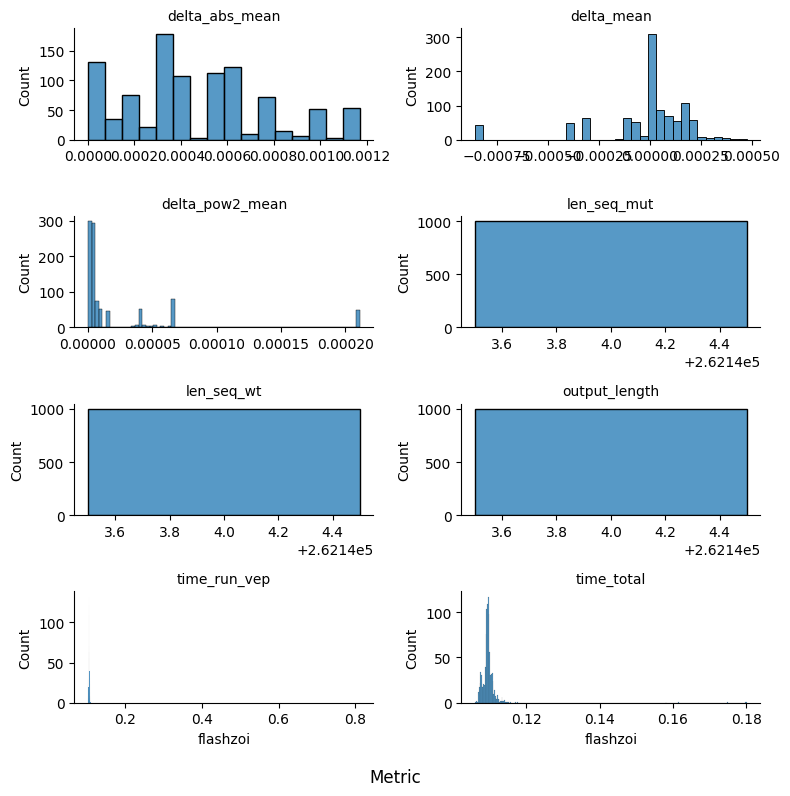

In [365]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with subplots for each slot
g = sns.FacetGrid(vep_df.groupby("slot").sample(1000).sort_values("slot"),
                  col="slot",  # Changed from row to col
                  col_wrap=2,  # Added col_wrap to wrap facets
                  height=2, 
                  aspect=2, 
                  margin_titles=True,
                  sharex=False, 
                  sharey=False)
g.map_dataframe(sns.histplot, x="flashzoi")
g.set_titles("{col_name}")
g.fig.supxlabel("Metric")
plt.tight_layout()

## Annotate VEP results with variant metadata

In [366]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz", simplify=True) 

print("bed shape:",bed_utr.shape)
print("vep_df shape:",vep_df.shape)

print(bed_utr["CLNSIG"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIG_simple"].value_counts().sort(by="count", descending=True))
print(bed_utr["CLNSIG_super_simple"].value_counts().sort(by="count", descending=True))

bed shape: (13771, 25)
vep_df shape: (774744, 12)
shape: (9, 2)
┌─────────────────────────────────┬───────┐
│ CLNSIG                          ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Benign                          ┆ 8029  │
│ Likely_benign                   ┆ 1851  │
│ Benign/Likely_benign            ┆ 1836  │
│ Pathogenic/Likely_pathogenic    ┆ 917   │
│ Pathogenic                      ┆ 846   │
│ Likely_pathogenic               ┆ 288   │
│ Pathogenic/Likely_pathogenic/P… ┆ 2     │
│ Benign|confers_sensitivity      ┆ 1     │
│ Benign|other                    ┆ 1     │
└─────────────────────────────────┴───────┘
shape: (4, 2)
┌───────────────┬───────┐
│ CLNSIG_simple ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ benign        ┆ 8031  │
│ likely_benign ┆ 3687  │
│ likely_path   ┆ 1207  │
│ path          ┆ 846   │
└───────────────┴───────┘
sh

In [368]:
vep_df2 = vep_df.merge(bed_utr.to_pandas(), 
                       left_on="site", 
                       right_on="name")

print("Merged vep_df/bed shape:",vep_df2.shape)
print("\n",vep_df2["CLNSIG"].value_counts().sort_values(ascending=False))
print("\n",vep_df2["CLNSIG_simple"].value_counts().sort_values(ascending=False))
print("\n",vep_df2["CLNSIG_super_simple"].value_counts().sort_values(ascending=False))

Merged vep_df/bed shape: (774744, 37)

 CLNSIG
Benign                          407760
Pathogenic                      122328
Likely_benign                    81552
Benign/Likely_benign             81552
Pathogenic/Likely_pathogenic     81552
Name: count, dtype: int64

 CLNSIG_simple
benign           407760
likely_benign    163104
path             122328
likely_path       81552
Name: count, dtype: int64

 CLNSIG_super_simple
benign    570864
path      203880
Name: count, dtype: int64


## Estimate total time

Based on the existing results, estimate how long it will take to run all selected ClinVar variants. 

In [370]:
model_name = "flashzoi"
n_gpus = 1

time_df =  vep_df.loc[vep_df["slot"]=="time_total"]
seconds_per_site = time_df.groupby("site")[model_name].sum().mean()
print(f"{seconds_per_site/60:.2f} minutes per site")
print(f"Number of days it should take to run all sites genome-wide: {seconds_per_site * bed_utr["name"].n_unique() / 60 / 60 / 24 / n_gpus:.2f}")

9.32 minutes per site
Number of days it should take to run all sites genome-wide: 89.09


In [371]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, Normalizer
# scaler = MinMaxScaler()
scaler = RobustScaler()
# scaler = Normalizer()

delta_df = vep_df2.loc[vep_df2["slot"].str.startswith("delta_")].copy()

# Create scaler instance


# Group by site and slot, then apply minmax scaling
delta_df.loc[:,"flashzoi_norm"] = delta_df.groupby(["GENE","slot"])["flashzoi"].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).ravel() if len(x) > 0 else 0
)

 # Sort by scoring strategy
clinsig_col="CLNSIG_simple"
delta_df = utils.sort_by_reverse_string(delta_df, 
                                        column='slot',
                                        extra_sort_cols=[clinsig_col],
                                        ascending=[True, False])

In [372]:
delta_df.loc[delta_df["CLNSIG_simple"]=="path"]["flashzoi_norm"].describe()

count    45873.000000
mean        -0.015620
std          0.626571
min         -1.552665
25%          0.000000
50%          0.000000
75%          0.451918
max         26.242568
Name: flashzoi_norm, dtype: float64

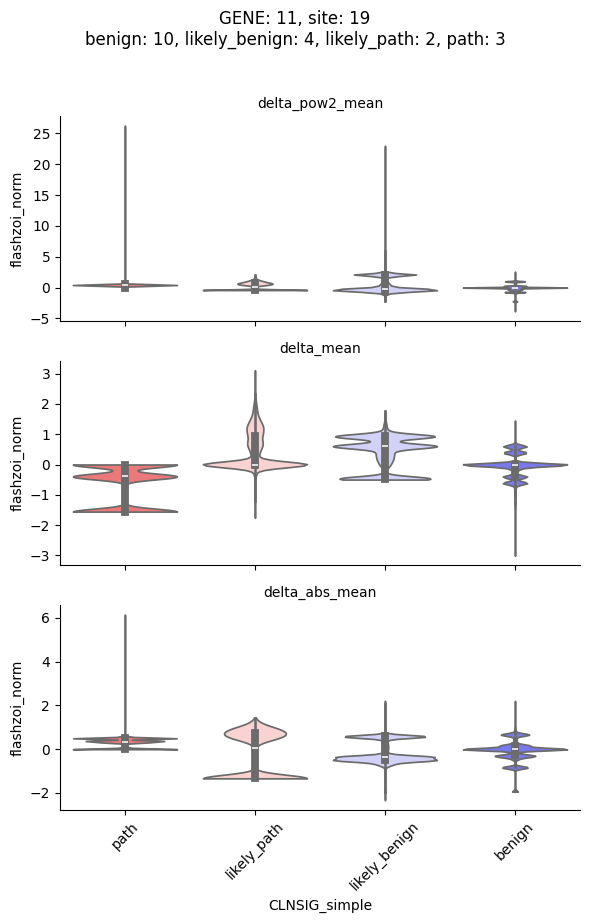

In [ ]:
# Filter for delta metrics and create violin plot with facets

g = sns.FacetGrid(delta_df, row="slot", height=3, aspect=2, sharey=False)
g.map_dataframe(sns.violinplot, 
                x="CLNSIG_simple", 
                y="flashzoi", 
                hue="CLNSIG_simple",
                palette=utils.get_clinsig_palette(),
                cut=0
                )
g.fig.suptitle(va.summarise_title(delta_df)+"\n"+ va.summarise_sites(delta_df), y=1.02)
g.set_titles("{row_name}")
plt.xticks(rotation=45)
plt.tight_layout()

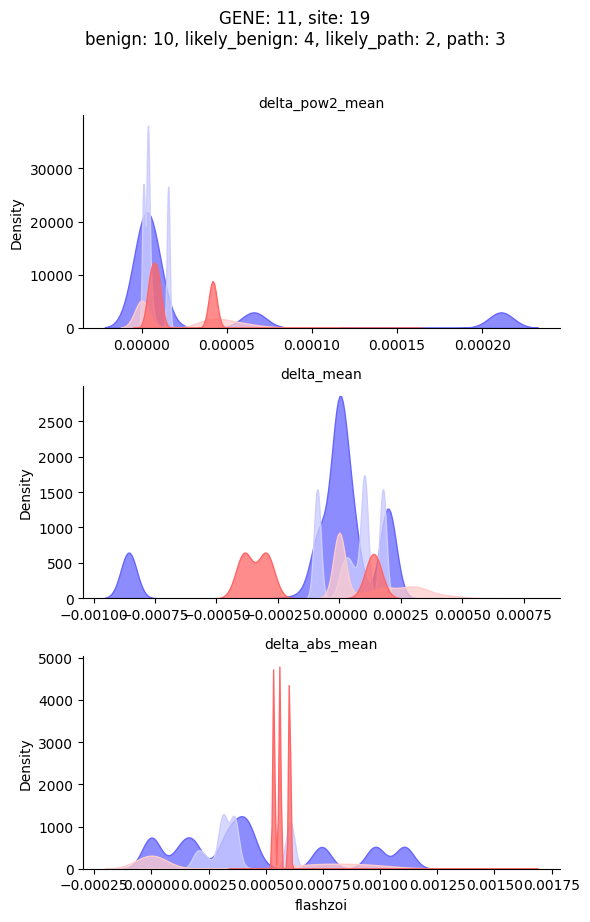

In [377]:
# Filter for delta metrics and create 2D density plot with facets

g = sns.FacetGrid(delta_df, 
                  row="slot", 
                  height=3, aspect=2, 
                  sharey=False, sharex=False)
g.map_dataframe(sns.kdeplot, 
                x="flashzoi", 
                hue="CLNSIG_simple",
                palette=utils.get_clinsig_palette(),
                alpha=.75,
                fill=True,  # Fill the KDE plot
                legend=True)
g.set_titles("{row_name}")
g.fig.suptitle(va.summarise_title(delta_df)+"\n"+ va.summarise_sites(delta_df), y=1.02)
plt.tight_layout()

# # Add legend with explicit legend handles
# handles, labels = g.axes[0,0].get_legend_handles_labels()
# g.fig.legend(handles, labels, title="Clinical Significance", 
#              bbox_to_anchor=(1.05, 0.5), loc='center left')